# cfRNA Normative Model CV 평가 요약
평가 지표: **W1 (1차 Wasserstein)**, **ETP (경험적 꼬리 확률)**, z-score 적률 (mean/std/skew/kurt), fold 성공률  
모델 색상: Set1 팔레트 첫 3개 — NBI: #E41A1C, ZINBI: #377EB8, Logistic: #4DAF4A

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

CV_DIR = Path('CV_Results')

# Set1 palette — first 3 colours
PALETTE = {'NBI': '#E41A1C', 'ZINBI': '#377EB8', 'Logistic': '#4DAF4A'}
MODEL_ORDER = ['NBI', 'ZINBI', 'Logistic']

def load_csv(path):
    return pd.read_csv(path) if path.exists() else None

def load_pkl(path):
    if not path.exists():
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

nb   = load_csv(CV_DIR / 'cv_gamlss_stats.csv')
zinb = load_csv(CV_DIR / 'cv_zinb_stats.csv')
logr = load_csv(CV_DIR / 'cv_logistic_stats.csv')

nb_z   = load_pkl(CV_DIR / 'cv_gamlss_zscores.pkl')   # {gene: (n,) array}
zinb_z = load_pkl(CV_DIR / 'cv_zinb_zscores.pkl')     # {gene: {'full':..., ...}}
logr_z = load_pkl(CV_DIR / 'cv_logistic_zscores.pkl') # {gene: (n,) array}

for name, df in [('NBI', nb), ('ZINBI', zinb), ('Logistic', logr)]:
    status = f'{len(df):,} genes' if df is not None else 'not found'
    print(f'{name:10s}: {status}')

NBI       : 12,396 genes
ZINBI     : 888 genes
Logistic  : 5,121 genes


## 1. 요약 통계표

In [2]:
ETP_THR = 1.96   # |z| > 1.96 → tail event; ~5% under N(0,1)
W1_EXPECTED = 0.048  # expected W1 for perfect N(0,1) at n≈693

# Metric definitions: (column, display label, plot xlim, reference value)
METRIC_DEFS = [
    ('w1',     'W1 ↓',           (0.0,  0.40),  W1_EXPECTED),
    ('etp',    'ETP ↓ (→0.05)', (0.0,  0.20),  0.05),
    ('skew_z', 'Skewness → 0',  (-2.0, 2.0),   0.0),
    ('kurt_z', 'Kurtosis → 0',  (-1.0, 6.0),   0.0),
    ('mean_z', 'Z-mean → 0',    (-0.4, 0.4),   0.0),
    ('std_z',  'Z-std → 1',     (0.6,  1.4),   1.0),
]

def _get_zarr(z_dict, gene, z_type):
    if z_dict is None:
        return None
    entry = z_dict.get(gene)
    if entry is None:
        return None
    return entry.get(z_type) if isinstance(entry, dict) else entry

def _w1(arr):
    v = arr[np.isfinite(arr)]
    n = len(v)
    if n < 8:
        return np.nan
    ref = norm.ppf(np.linspace(1 / (2 * n), 1 - 1 / (2 * n), n))
    return float(np.mean(np.abs(np.sort(v) - ref)))

def _etp(arr, thr=ETP_THR):
    v = arr[np.isfinite(arr)]
    return float(np.mean(np.abs(v) > thr)) if len(v) >= 8 else np.nan

def extract_metrics(df, label, mz_col, sz_col, sk_col, ku_col,
                    success_col, z_dict, z_type='full',
                    w1_col=None, flag_col=None):
    if df is None:
        return None
    genes  = df['gene'].values
    n      = len(genes)
    w1_arr = df[w1_col].values.astype(float) if (w1_col and w1_col in df.columns) \
             else np.full(n, np.nan)
    etp_arr = np.full(n, np.nan)

    for i, gene in enumerate(genes):
        arr = _get_zarr(z_dict, gene, z_type)
        if arr is None:
            continue
        if np.isnan(w1_arr[i]):
            w1_arr[i] = _w1(arr)
        etp_arr[i] = _etp(arr)

    return pd.DataFrame({
        'model':     label,
        'gene':      genes,
        'det_rate':  df['det_rate_hc'].values.astype(float),
        'w1':        w1_arr,
        'etp':       etp_arr,
        'mean_z':    df[mz_col].values.astype(float),
        'std_z':     df[sz_col].values.astype(float),
        'skew_z':    df[sk_col].values.astype(float),
        'kurt_z':    df[ku_col].values.astype(float),
        'fold_ok':   df[success_col].values.astype(float),
        'any_flag':  df[flag_col].astype(bool).values
                     if (flag_col and flag_col in df.columns)
                     else np.zeros(n, bool),
        'n_removed': df['n_removed'].values.astype(float)
                     if 'n_removed' in df.columns else np.zeros(n),
    })

frames = []
if nb is not None:
    frames.append(extract_metrics(nb, 'NBI',
        'mean_z', 'std_z', 'skew_z', 'kurt_z', 'fold_success_rate',
        nb_z, z_type='full', w1_col='w1'))
if zinb is not None:
    frames.append(extract_metrics(zinb, 'ZINBI',
        'mean_full_z', 'std_full_z', 'skew_full_z', 'kurt_full_z',
        'fold_success_rate', zinb_z, z_type='full',
        w1_col='w1_full', flag_col='any_flag'))
if logr is not None:
    frames.append(extract_metrics(logr, 'Logistic',
        'mean_z', 'std_z', 'skew_z', 'kurt_z', 'fold_success_rate',
        logr_z, z_type='full', flag_col='any_flag'))

all_df = pd.concat(frames, ignore_index=True)
models_present = [m for m in MODEL_ORDER if m in all_df['model'].unique()]

# ── Summary table (Median + IQR) ─────────────────────────────────
rows_tbl = []
for model in models_present:
    sub = all_df[all_df['model'] == model]
    row = {'Model': model, 'N': f'{len(sub):,}',
           'Flag %': f'{sub["any_flag"].mean()*100:.1f}%',
           'Fold ok': f'{(sub["fold_ok"]==1.0).mean()*100:.1f}%'}
    for col, label, _, _ in METRIC_DEFS:
        v = sub[col].dropna()
        q25, med, q75 = v.quantile([0.25, 0.5, 0.75])
        row[label] = f'{med:.3f}  ({q25:.3f}–{q75:.3f})'
    rows_tbl.append(row)

summary_df = pd.DataFrame(rows_tbl).set_index('Model')
summary_df

,N,Flag %,Fold ok,W1 ↓,ETP ↓ (→0.05),Skewness → 0,Kurtosis → 0,Z-mean → 0,Z-std → 1
Model,,,,,,,,,
NBI,"12,396",0.0%,99.4%,0.063 (0.052–0.075),0.062 (0.056–0.068),-0.081 (-0.239–0.083),0.713 (0.323–1.228),0.005 (-0.001–0.012),1.061 (1.050–1.072)
ZINBI,888,43.1%,98.4%,0.052 (0.043–0.065),0.056 (0.050–0.062),0.209 (0.056–0.353),0.454 (0.121–0.980),0.018 (0.007–0.028),1.032 (1.015–1.051)
Logistic,"5,121",0.0%,100.0%,0.045 (0.039–0.050),0.045 (0.040–0.048),0.050 (0.010–0.092),0.293 (0.185–0.409),0.003 (-0.000–0.008),0.968 (0.959–0.978)


## 2. 지표별 분포 (모델 × 6 지표)

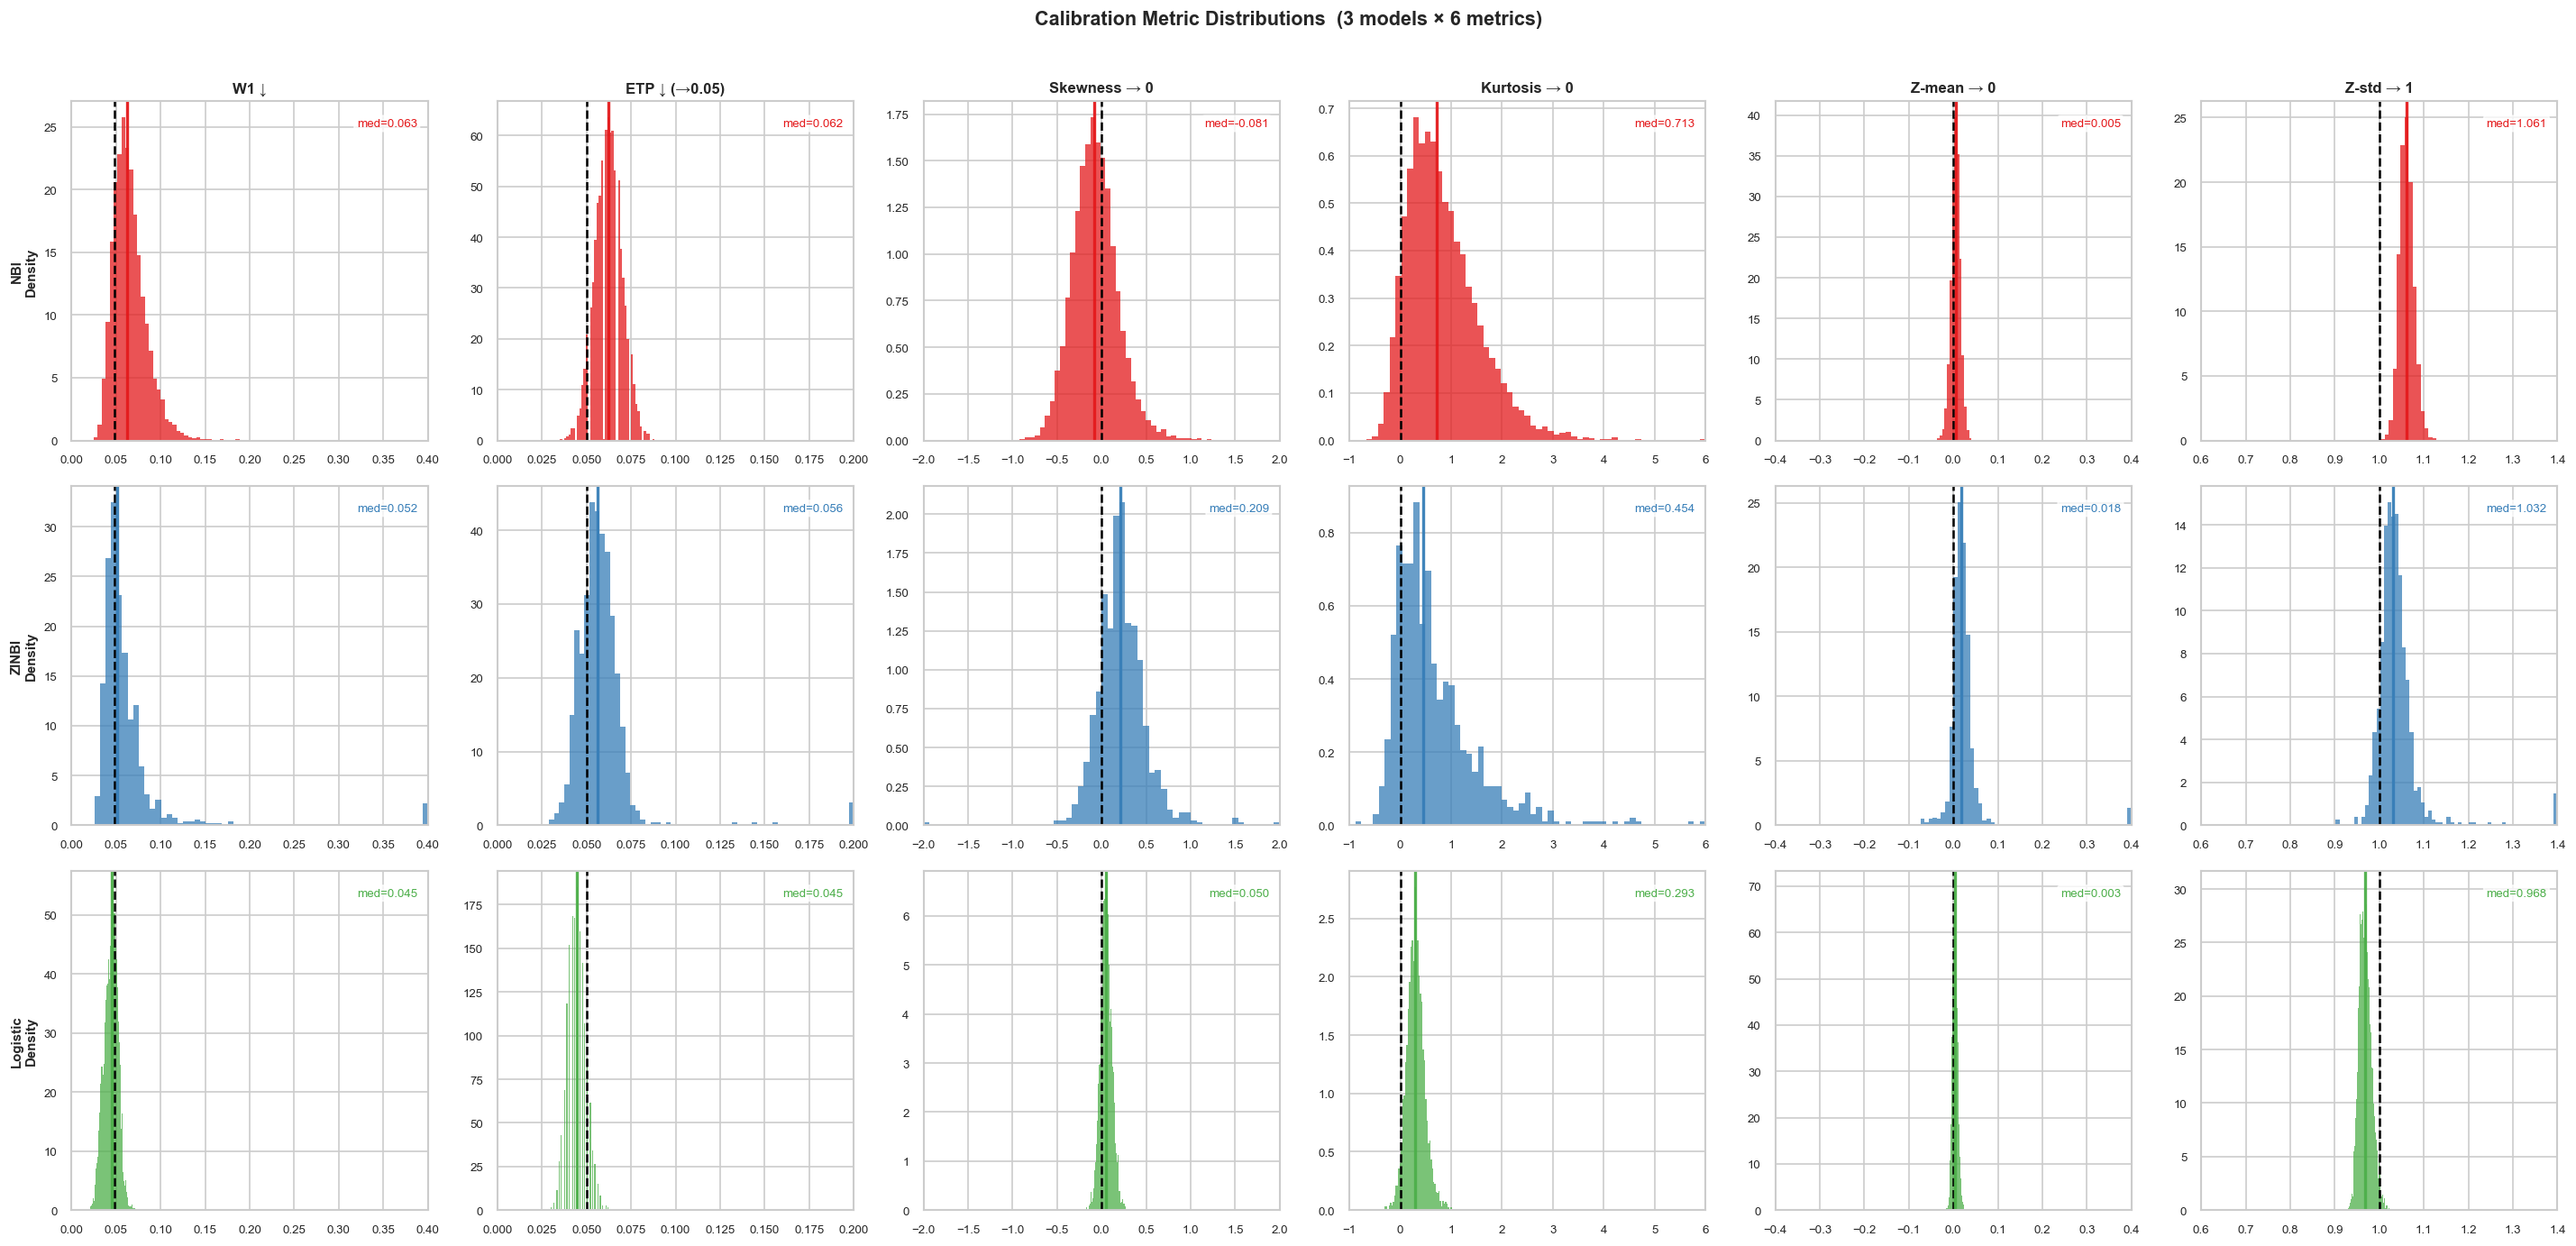

In [3]:
n_models = len(models_present)
fig, axes = plt.subplots(n_models, 6,
                          figsize=(24, 3.8 * n_models),
                          squeeze=False)

for row, model in enumerate(models_present):
    sub   = all_df[all_df['model'] == model]
    color = PALETTE[model]

    for col, (metric, label, xlim, ref) in enumerate(METRIC_DEFS):
        ax   = axes[row, col]
        vals = sub[metric].dropna().clip(*xlim)
        med  = vals.median()

        ax.hist(vals, bins=60, color=color, alpha=0.75,
                density=True, edgecolor='none')
        ax.axvline(ref, color='black', lw=1.5, ls='--')
        ax.axvline(med, color=color,   lw=2.0, ls='-', alpha=0.95)
        ax.set_xlim(*xlim)
        ax.tick_params(labelsize=8)

        if col == 0:
            ax.set_ylabel(f'{model}\nDensity', fontweight='bold', fontsize=9)
        else:
            ax.set_ylabel('')

        if row == 0:
            ax.set_title(label, fontweight='bold', fontsize=10)

        ax.annotate(f'med={med:.3f}',
                    xy=(0.97, 0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=8, color=color,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75))

plt.suptitle(f'Calibration Metric Distributions  ({n_models} models × 6 metrics)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_metrics_grid.png', bbox_inches='tight')
plt.show()

## 3. FLAG 분석

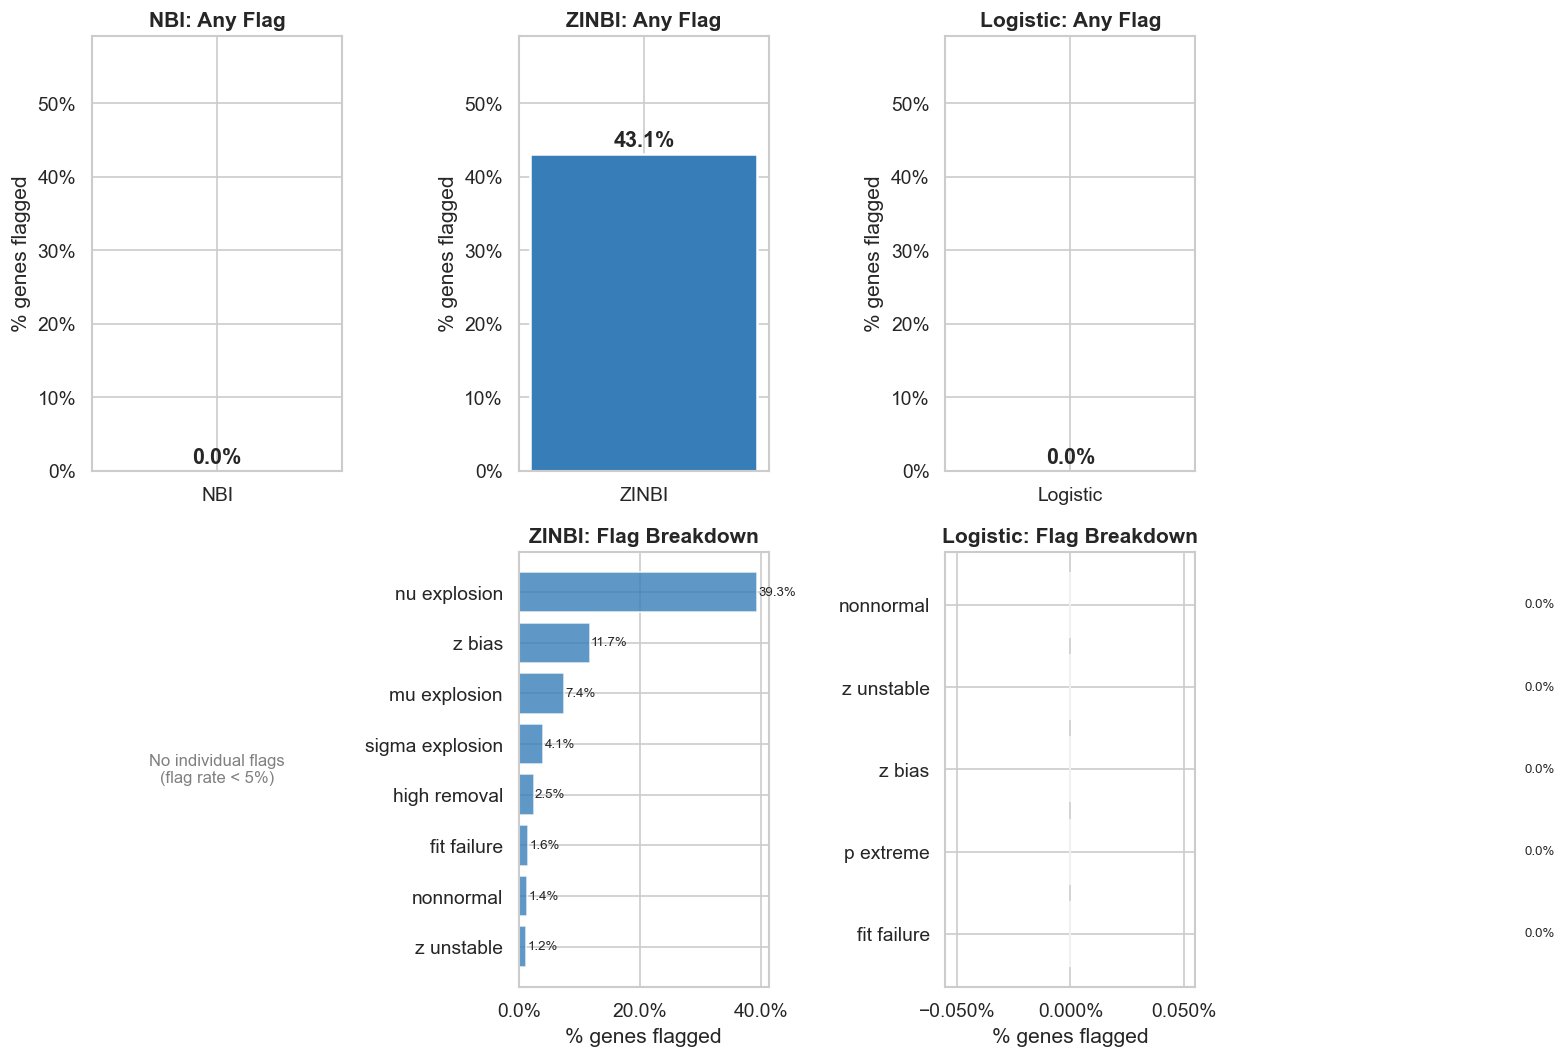

In [4]:
flag_rates = {m: all_df[all_df['model'] == m]['any_flag'].mean() * 100
              for m in models_present}
has_many   = any(r > 5 for r in flag_rates.values())

src_map   = {'NBI': nb, 'ZINBI': zinb, 'Logistic': logr}
n_cols    = len(models_present)
fig_rows  = 2 if has_many else 1
fig, axes = plt.subplots(fig_rows, n_cols,
                          figsize=(5 * n_cols, 4.5 * fig_rows),
                          squeeze=False)

# Row 0: Flag rate bar
for ci, model in enumerate(models_present):
    ax   = axes[0, ci]
    rate = flag_rates[model]
    ax.bar([model], [rate], color=PALETTE[model], edgecolor='white', linewidth=1.5)
    ax.text(0, rate + 0.4, f'{rate:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=13)
    ax.set_ylim(0, max(max(flag_rates.values()) * 1.30 + 3, 10))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f'{model}: Any Flag', fontweight='bold')
    ax.set_ylabel('% genes flagged')

# Row 1: Individual flag breakdown (when many flags exist)
if has_many:
    for ci, model in enumerate(models_present):
        ax   = axes[1, ci]
        df_m = src_map.get(model)
        flag_cols = [c for c in (df_m.columns if df_m is not None else [])
                     if c.startswith('flag_') and c != 'any_flag']
        if flag_cols:
            pcts   = (df_m[flag_cols].mean() * 100).sort_values(ascending=True)
            labels = [c.replace('flag_', '').replace('_', ' ') for c in pcts.index]
            bars   = ax.barh(labels, pcts.values,
                             color=PALETTE[model], alpha=0.8, edgecolor='white')
            for bar, v in zip(bars, pcts.values):
                ax.text(v + 0.2, bar.get_y() + bar.get_height() / 2,
                        f'{v:.1f}%', va='center', fontsize=8)
            ax.set_title(f'{model}: Flag Breakdown', fontweight='bold')
            ax.set_xlabel('% genes flagged')
            ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        else:
            ax.text(0.5, 0.5, 'No individual flags\n(flag rate < 5%)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=10, color='grey')
            ax.axis('off')

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_flags.png', bbox_inches='tight')
plt.show()

## 4. Detection Rate별 분포

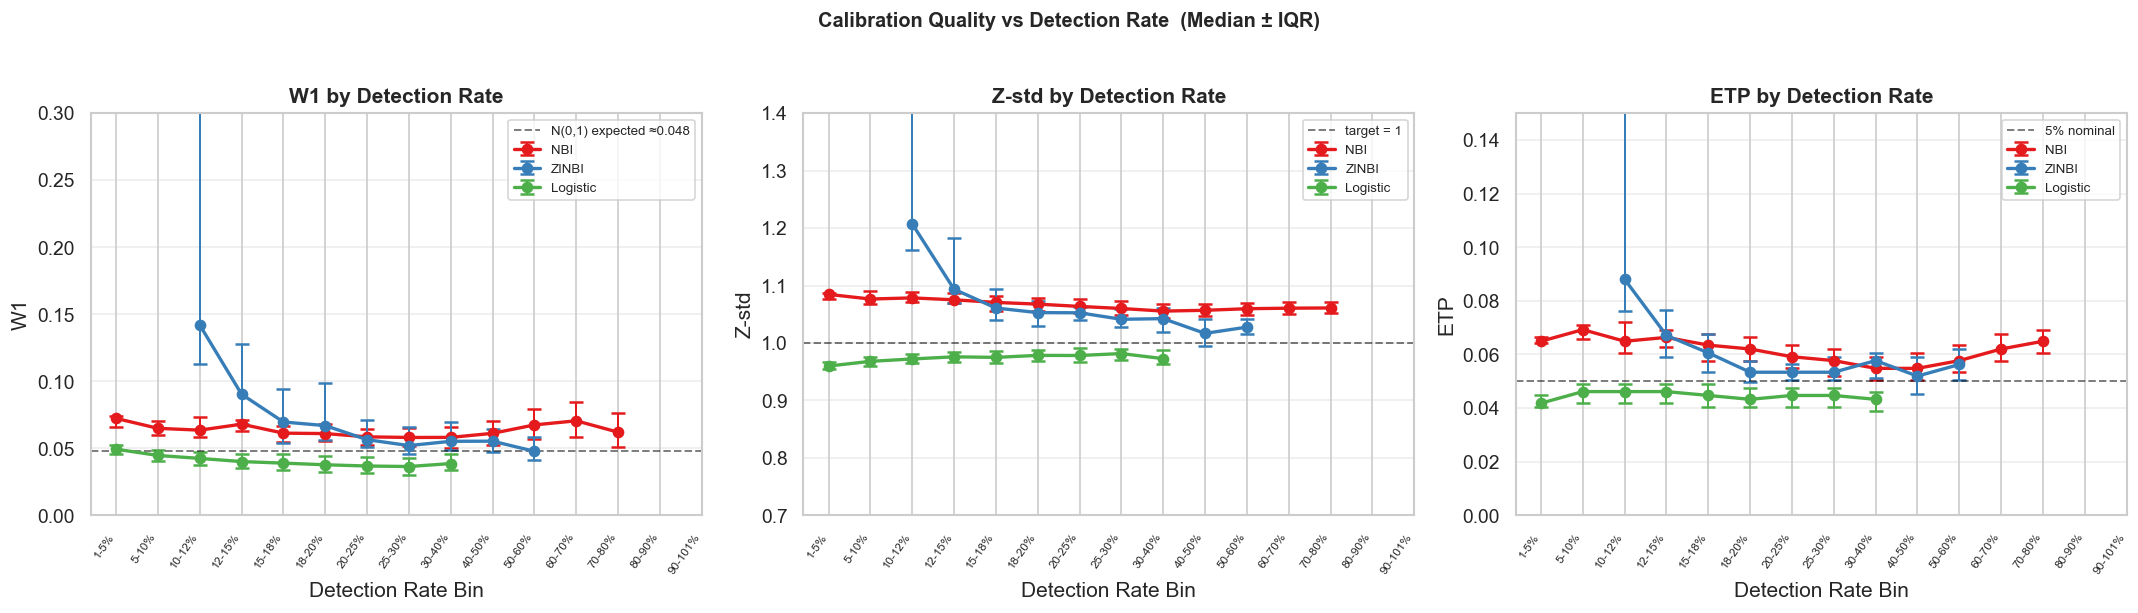

In [5]:
# Finer bins — covers both Logistic range (<10%) and NBI/ZINBI range (≥10%)
DET_BINS = np.array([0.01, 0.05, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25,
                     0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.01])
DET_LABELS = [f'{int(DET_BINS[i]*100)}-{int(DET_BINS[i+1]*100)}%'
              for i in range(len(DET_BINS) - 1)]

EB_METRICS = [
    ('w1',    'W1',    (0.00, 0.30), W1_EXPECTED, f'N(0,1) expected ≈{W1_EXPECTED}'),
    ('std_z', 'Z-std', (0.70, 1.40), 1.0,         'target = 1'),
    ('etp',   'ETP',   (0.00, 0.15), 0.05,        '5% nominal'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, label, ylim, ref, ref_label) in zip(axes, EB_METRICS):
    for model in models_present:
        sub = all_df[all_df['model'] == model].copy()
        sub['det_bin'] = pd.cut(sub['det_rate'], bins=DET_BINS,
                                 labels=DET_LABELS, right=False)
        grp = sub.groupby('det_bin', observed=True)[metric]
        med, q25, q75, cnt = (grp.median(), grp.quantile(0.25),
                               grp.quantile(0.75), grp.count())
        x    = np.arange(len(med))
        mask = cnt > 2
        ax.errorbar(x[mask], med.values[mask],
                    yerr=[med.values[mask] - q25.values[mask],
                          q75.values[mask] - med.values[mask]],
                    fmt='o-', color=PALETTE[model], label=model,
                    lw=2, ms=6, capsize=4, capthick=1.5, elinewidth=1.2)

    ax.axhline(ref, color='black', lw=1.2, ls='--', alpha=0.5, label=ref_label)
    ax.set_xticks(range(len(DET_LABELS)))
    ax.set_xticklabels(DET_LABELS, rotation=55, ha='right', fontsize=7)
    ax.set_ylim(*ylim)
    ax.set_title(f'{label} by Detection Rate', fontweight='bold')
    ax.set_xlabel('Detection Rate Bin')
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.35)

plt.suptitle('Calibration Quality vs Detection Rate  (Median ± IQR)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_detrate.png', bbox_inches='tight')
plt.show()

## 5. Outlier 제거 분포 & Fold 100% 성공률

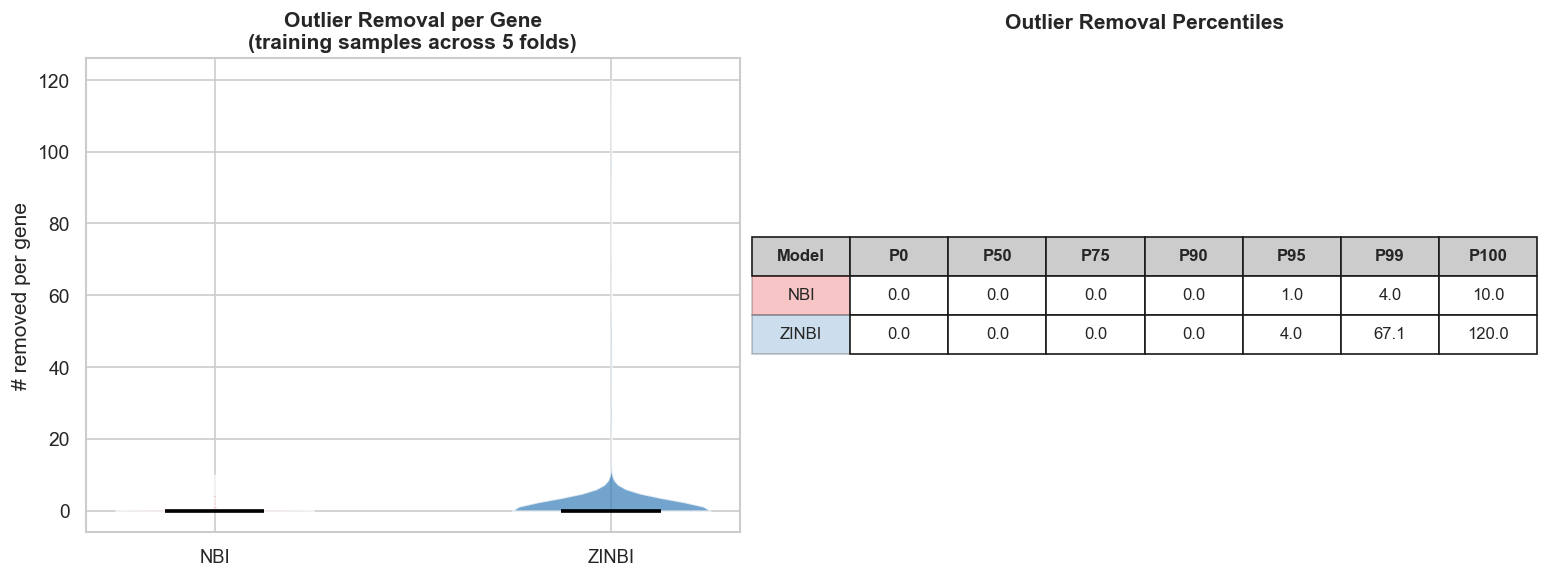

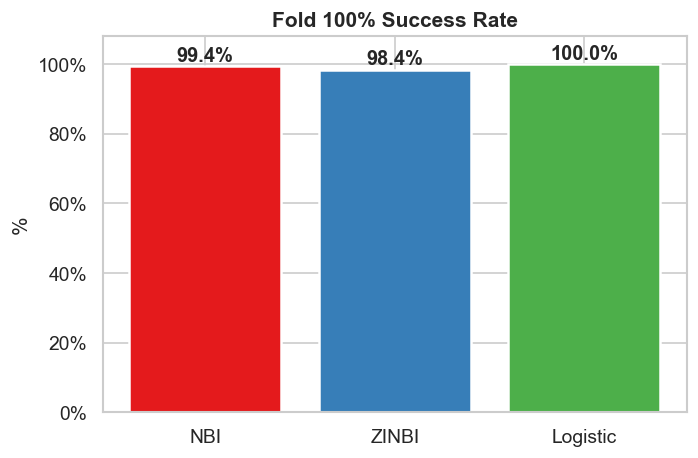

In [6]:
# ── Outlier removal: violin + percentile table ────────────────────
count_models = [m for m in models_present if m != 'Logistic']

fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))

# Left: violin
ax = axes1[0]
if count_models:
    data  = [all_df[all_df['model'] == m]['n_removed'].values for m in count_models]
    parts = ax.violinplot(data, positions=range(len(count_models)),
                           showmedians=True, showextrema=False)
    for pc, model in zip(parts['bodies'], count_models):
        pc.set_facecolor(PALETTE[model]); pc.set_alpha(0.70)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2.2)
    ax.set_xticks(range(len(count_models)))
    ax.set_xticklabels(count_models, fontsize=11)
ax.set_title('Outlier Removal per Gene\n(training samples across 5 folds)',
             fontweight='bold')
ax.set_ylabel('# removed per gene')

# Right: percentile table
ax = axes1[1]; ax.axis('off')
pctiles   = [0, 50, 75, 90, 95, 99, 100]
rows_t    = []
for model in count_models:
    vals = all_df[all_df['model'] == model]['n_removed']
    rows_t.append([model] + [f'{np.percentile(vals, p):.1f}' for p in pctiles])

if rows_t:
    col_labels = ['Model'] + [f'P{p}' for p in pctiles]
    tbl = ax.table(cellText=rows_t, colLabels=col_labels,
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    tbl.scale(1.2, 1.9)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#cccccc')
            cell.set_text_props(fontweight='bold')
        elif c == 0:
            m = rows_t[r - 1][0]
            cell.set_facecolor(PALETTE[m]); cell.set_alpha(0.25)
ax.set_title('Outlier Removal Percentiles', fontweight='bold', pad=18)

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_outlier.png', bbox_inches='tight')
plt.show()

# ── Fold 100% success rate ────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(6, 4))
fold_ok_full = (all_df.groupby('model')['fold_ok']
                .apply(lambda x: (x == 1.0).mean() * 100)
                .reindex(models_present))
bars = ax.bar(fold_ok_full.index, fold_ok_full.values,
              color=[PALETTE[m] for m in fold_ok_full.index],
              edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, fold_ok_full.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Fold 100% Success Rate', fontweight='bold')
ax.set_ylabel('%')
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_fold_success.png', bbox_inches='tight')
plt.show()

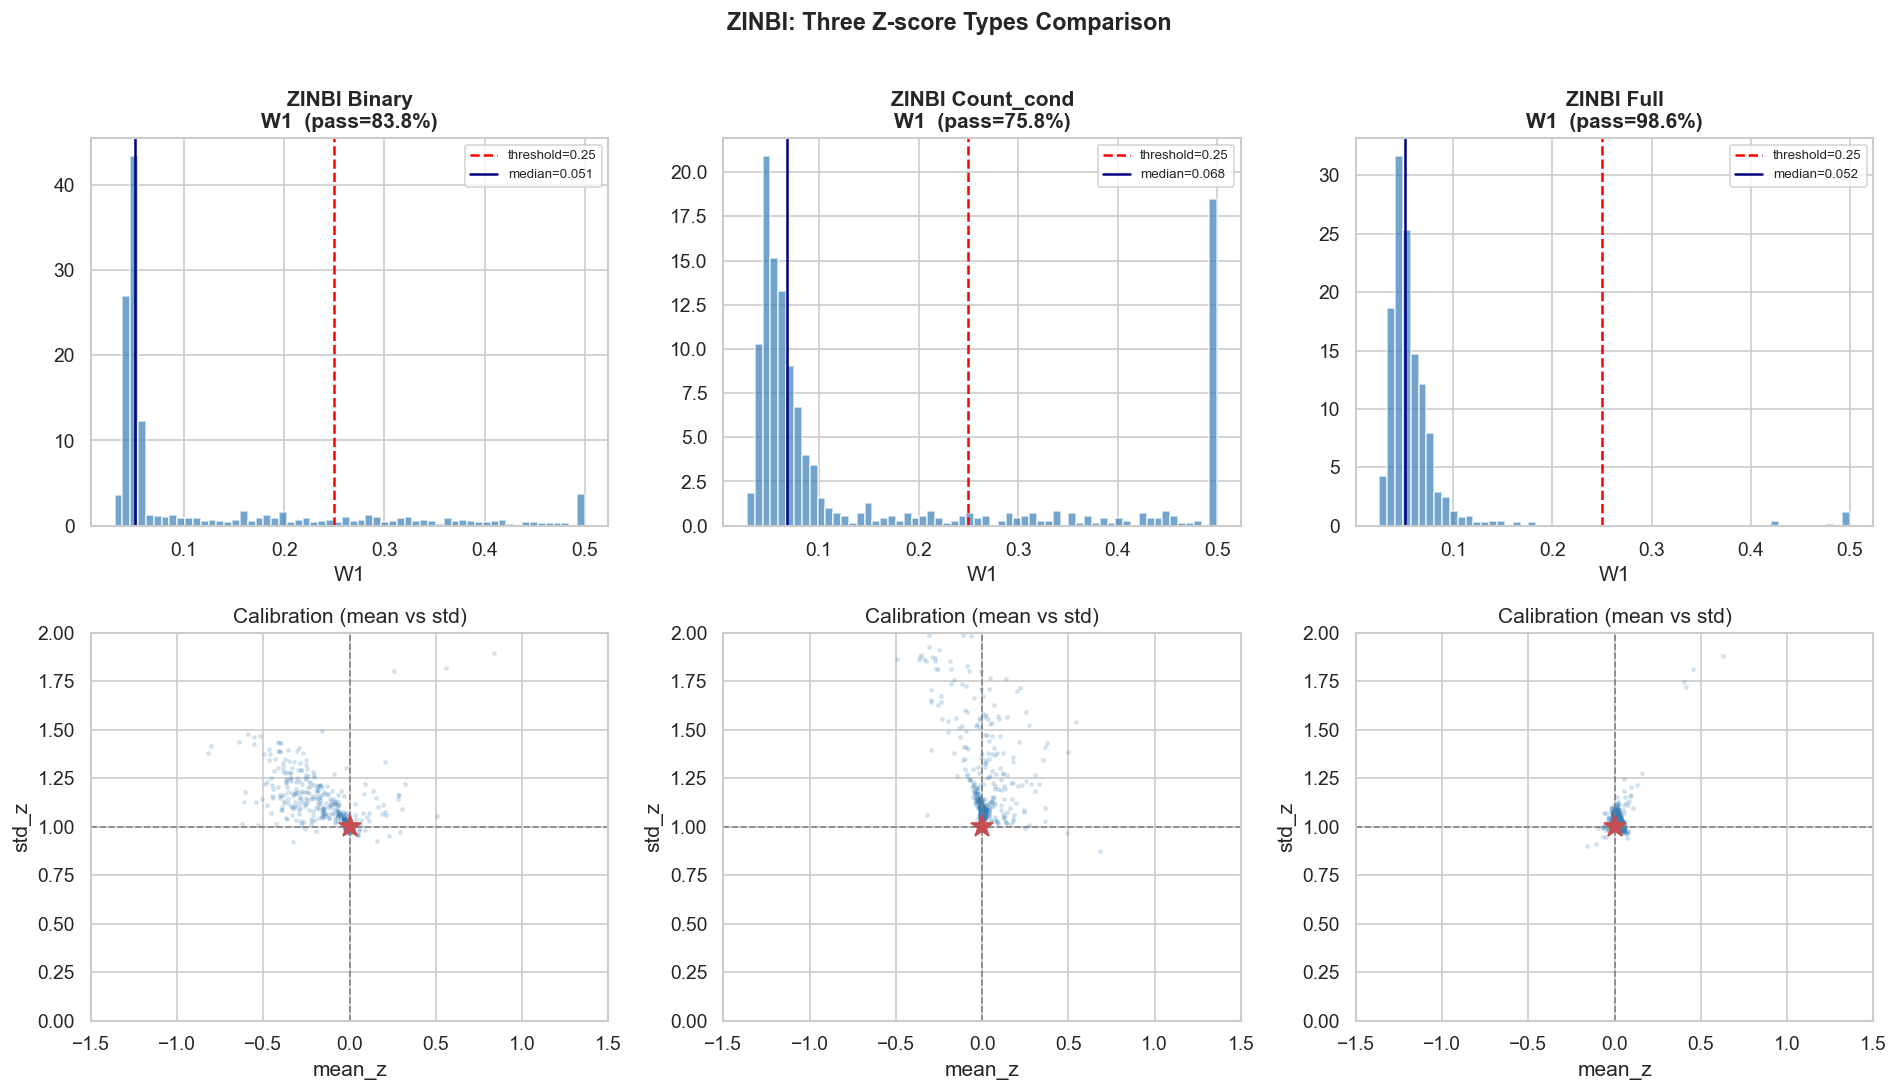

In [8]:
# ── ZINBI: Three Z-score Types ────────────────────────────────────
if zinb is not None:
    W1_THR = 0.25
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    zscore_types = [
        ('Binary',     'w1_binary',    'mean_binary_z',    'std_binary_z'),
        ('Count_cond', 'w1_count_cond','mean_count_cond_z','std_count_cond_z'),
        ('Full',       'w1_full',      'mean_full_z',      'std_full_z'),
    ]

    for ci, (ztype, w1_col, mz_col, sz_col) in enumerate(zscore_types):
        ax_w1  = axes[0, ci]
        ax_cal = axes[1, ci]

        # W1 distribution
        vals = zinb[w1_col].dropna().clip(0, 0.5)
        ax_w1.hist(vals, bins=60, color=PALETTE['ZINBI'], alpha=0.7, density=True)
        ax_w1.axvline(W1_THR, color='red',  lw=1.5, ls='--',
                      label=f'threshold={W1_THR}')
        med_w1 = zinb[w1_col].median()
        ax_w1.axvline(med_w1, color='navy', lw=1.5, ls='-',
                      label=f'median={med_w1:.3f}')
        pass_rate = (zinb[w1_col] <= W1_THR).mean() * 100
        ax_w1.set_title(f'ZINBI {ztype}\nW1  (pass={pass_rate:.1f}%)',
                        fontweight='bold')
        ax_w1.set_xlabel('W1'); ax_w1.legend(fontsize=8)

        # Calibration scatter
        mz = zinb[mz_col].dropna()
        sz = zinb[sz_col].dropna()
        idx = mz.index.intersection(sz.index)
        ax_cal.scatter(mz[idx], sz[idx], alpha=0.15, s=4, color=PALETTE['ZINBI'])
        ax_cal.axvline(0, color='grey', lw=1, ls='--')
        ax_cal.axhline(1, color='grey', lw=1, ls='--')
        ax_cal.plot(0, 1, 'r*', ms=14, zorder=5)
        ax_cal.set_xlim(-1.5, 1.5); ax_cal.set_ylim(0, 2)
        ax_cal.set_xlabel('mean_z'); ax_cal.set_ylabel('std_z')
        ax_cal.set_title('Calibration (mean vs std)')

    plt.suptitle('ZINBI: Three Z-score Types Comparison',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(CV_DIR / 'fig_zinbi_zscore_types.png', bbox_inches='tight')
    plt.show()
else:
    print('ZINBI results not yet available.')

## 6. Per-gene Z-score Calibration

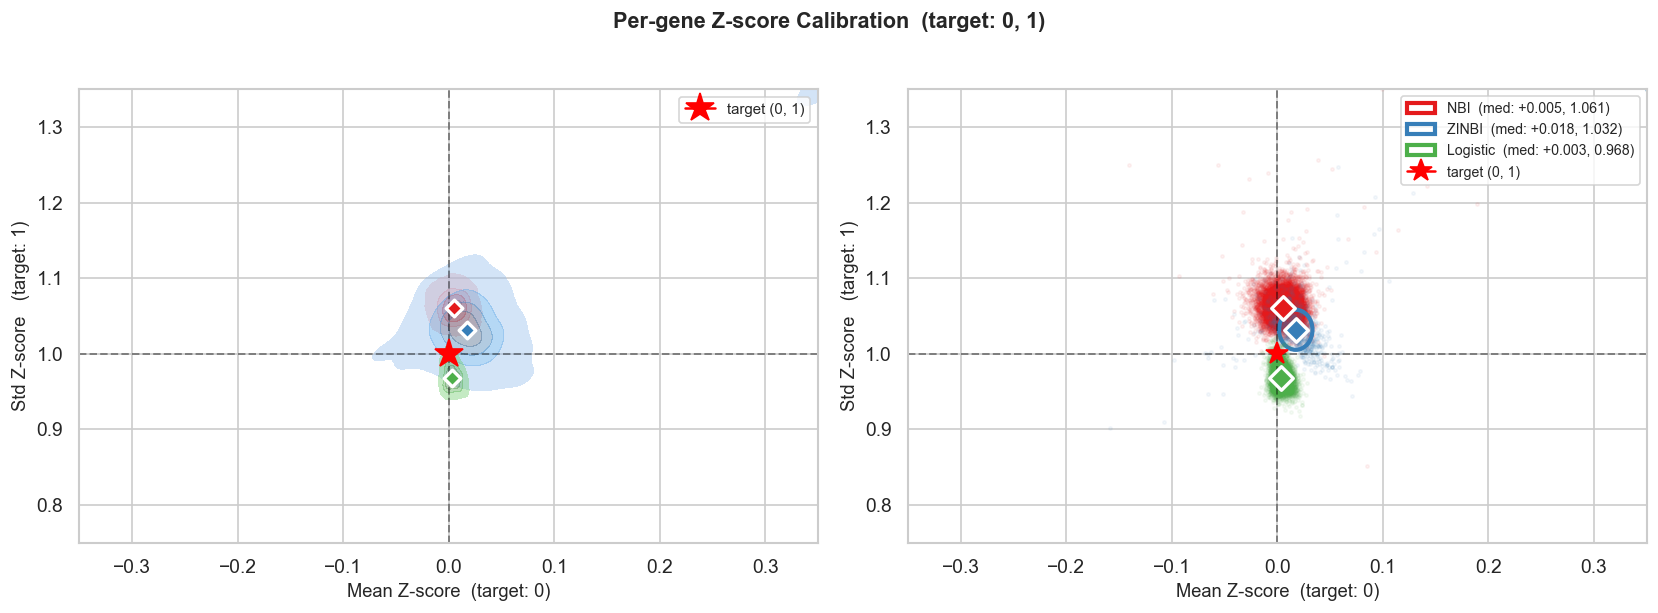

Model         med mean_z  med std_z  |mean_z|<0.1 %  |std_z-1|<0.1 %
------------------------------------------------------------------
NBI              +0.0054     1.0607          100.0%            98.2%
ZINBI            +0.0175     1.0315           98.2%            96.3%
Logistic         +0.0035     0.9677          100.0%           100.0%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xlim = (-0.35, 0.35)
ylim = (0.75, 1.35)

# ── Left: 2D KDE contour ──────────────────────────────────────────
ax = axes[0]
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    mz  = sub['mean_z'].clip(*xlim)
    sz  = sub['std_z'].clip(*ylim)
    sns.kdeplot(x=mz, y=sz, ax=ax, label=model,
                color=PALETTE[model], levels=5,
                fill=True, alpha=0.40, linewidths=1.5)
    ax.scatter(mz.median(), sz.median(), color=PALETTE[model],
               s=50, zorder=6, edgecolors='white', linewidth=2, marker='D')
ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.4)
ax.axhline(1, color='black', lw=1.2, ls='--', alpha=0.4)
ax.plot(0, 1, marker='*', ms=18, color='red', zorder=7, label='target (0, 1)')
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel('Mean Z-score  (target: 0)', fontsize=11)
ax.set_ylabel('Std Z-score   (target: 1)', fontsize=11)
ax.legend(fontsize=9)

# ── Right: scatter + IQR ellipse ─────────────────────────────────
ax = axes[1]
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    mz  = sub['mean_z'].clip(*xlim)
    sz  = sub['std_z'].clip(*ylim)
    ax.scatter(mz, sz, alpha=0.05, s=4, color=PALETTE[model])
    q25_mz, q75_mz = mz.quantile(0.25), mz.quantile(0.75)
    q25_sz, q75_sz = sz.quantile(0.25), sz.quantile(0.75)
    ellipse = plt.matplotlib.patches.Ellipse(
        xy=(mz.median(), sz.median()),
        width=(q75_mz - q25_mz) * 1.5,
        height=(q75_sz - q25_sz) * 1.5,
        edgecolor=PALETTE[model], facecolor='none', lw=2.5,
        label=f'{model}  (med: {mz.median():+.3f}, {sz.median():.3f})'
    )
    ax.add_patch(ellipse)
    ax.scatter(mz.median(), sz.median(), color=PALETTE[model],
               s=100, zorder=6, edgecolors='white', linewidth=2, marker='D')
ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.4)
ax.axhline(1, color='black', lw=1.2, ls='--', alpha=0.4)
ax.plot(0, 1, marker='*', ms=14, color='red', zorder=7, label='target (0, 1)')
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel('Mean Z-score  (target: 0)', fontsize=11)
ax.set_ylabel('Std Z-score   (target: 1)', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right')

plt.suptitle('Per-gene Z-score Calibration  (target: 0, 1)',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_calibration_2d.png', bbox_inches='tight')
plt.show()

print(f"{'Model':<12} {'med mean_z':>11} {'med std_z':>10} "
      f"{'|mean_z|<0.1 %':>15} {'|std_z-1|<0.1 %':>16}")
print('-' * 66)
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    m   = sub['mean_z'].median()
    s   = sub['std_z'].median()
    pm  = (sub['mean_z'].abs() < 0.1).mean() * 100
    ps  = ((sub['std_z'] - 1).abs() < 0.1).mean() * 100
    print(f"{model:<12} {m:>+11.4f} {s:>10.4f} {pm:>14.1f}% {ps:>15.1f}%")

## 7. Posterior Predictive Check (PPC)

각 HC 샘플 i가 **test fold에 있을 때** 학습된 파라미터로 카운트를 시뮬레이션하고 실측과 비교합니다.

| 모델 | 파라미터 pkl | 시뮬레이션 |
|---|---|---|
| NBI | `cv_gamlss_nb_ppc.pkl` | Y_sim ~ NBI(μ_i, σ_i) |
| ZINBI | `cv_zinb_ppc.pkl` | Y_sim ~ ZINBI(μ_i, σ_i, ν_i) |

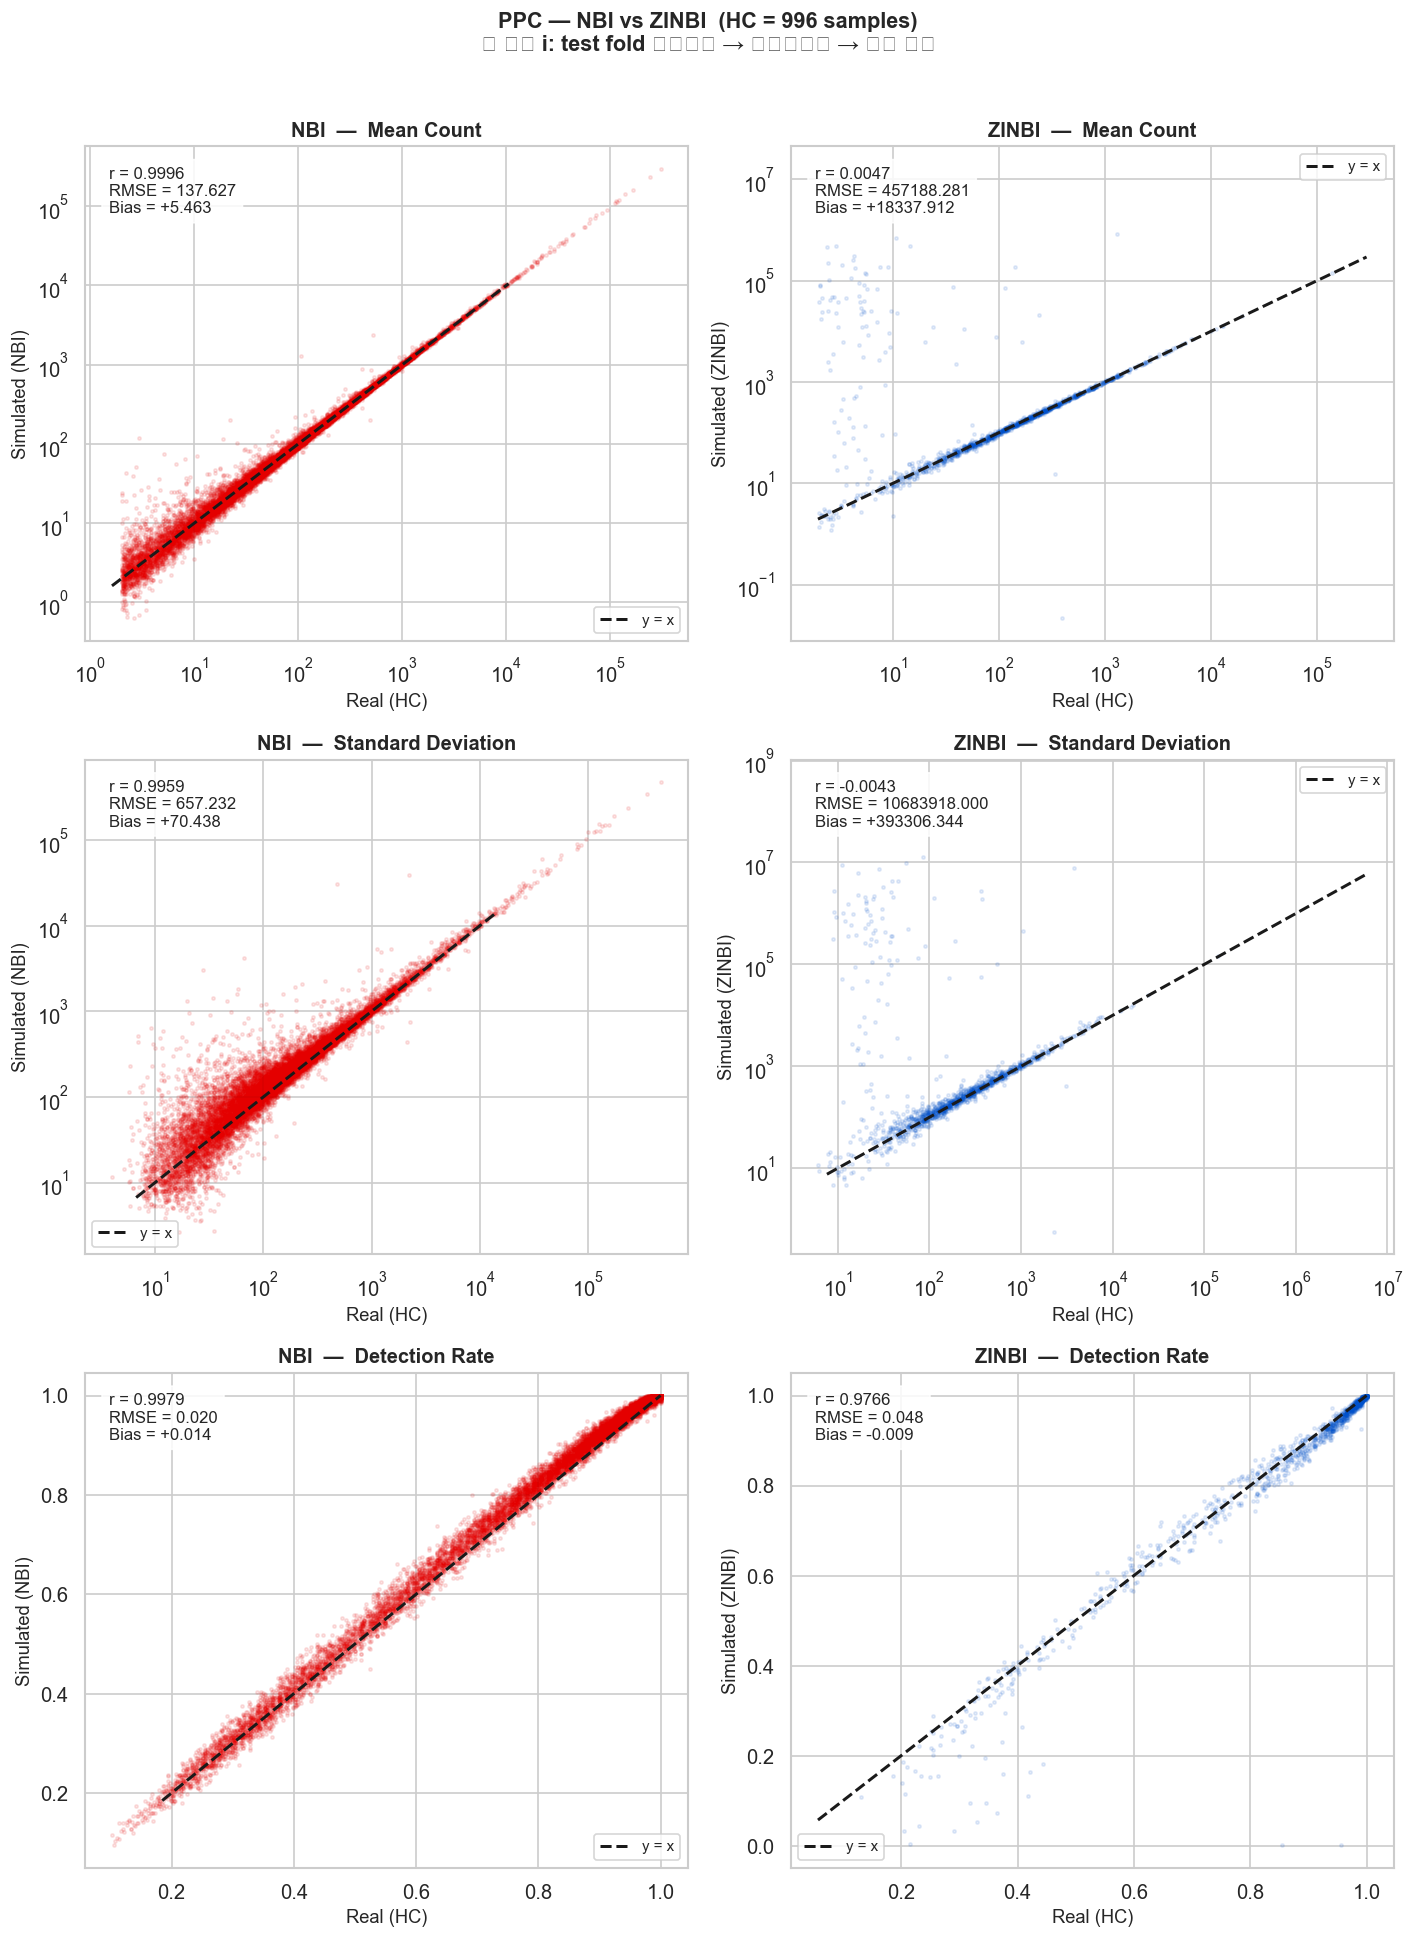


Model    Statistic                     r       RMSE         Bias
────────────────────────────────────────────────────────────────
NBI      Mean Count               0.9996    137.627       +5.463
NBI      Standard Deviation       0.9959    657.232      +70.438
NBI      Detection Rate           0.9979      0.020       +0.014

ZINBI    Mean Count               0.0047 457188.281   +18337.912
ZINBI    Standard Deviation      -0.0043 10683918.000  +393306.344
ZINBI    Detection Rate           0.9766      0.048       -0.009



In [ ]:

ppc_models = list(ppc_dfs.keys())
n_models   = len(ppc_models)

stats = [
    ('real_mean', 'sim_mean', 'Mean Count',      'log'),
    ('real_std',  'sim_std',  'Standard Deviation', 'log'),
    ('real_det',  'sim_det',  'Detection Rate',  'linear'),
]

fig, axes = plt.subplots(3, n_models,
                            figsize=(6 * n_models, 16), squeeze=False)

for col, model in enumerate(ppc_models):
    df    = ppc_dfs[model].dropna()
    color = palette.get(model, '#888888')
    n_g   = len(df)

    for row, (rx, sy, title, scale) in enumerate(stats):
        ax = axes[row, col]
        x  = df[rx].clip(lower=1e-3)
        y  = df[sy].clip(lower=1e-3)

        ax.scatter(x, y, alpha=0.10, s=4, color=color, rasterized=True)

        lo = min(x.quantile(0.005), y.quantile(0.005))
        hi = max(x.quantile(0.995), y.quantile(0.995))
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.8, label='y = x')

        v     = np.isfinite(x) & np.isfinite(y)
        corr  = np.corrcoef(x[v], y[v])[0, 1]
        rmse  = np.sqrt(((x[v] - y[v]) ** 2).mean())
        bias  = (y[v] - x[v]).mean()
        ax.text(0.04, 0.96,
                f'r = {corr:.4f}\nRMSE = {rmse:.3f}\nBias = {bias:+.3f}',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))

        if scale == 'log':
            ax.set_xscale('log'); ax.set_yscale('log')

        ax.set_xlabel('Real (HC)', fontsize=11)
        ax.set_ylabel(f'Simulated ({model})', fontsize=11)
        ax.set_title(f'{model}  —  {title}', fontweight='bold', fontsize=12)
        ax.legend(fontsize=9)

plt.suptitle(
    f'PPC — NBI vs ZINBI  (HC = 996 samples)\n'
    f'각 샘플 i: test fold 파라미터 → 시뮬레이션 → 실측 비교',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_ppc_fold.png', bbox_inches='tight', dpi=150)
plt.show()

# ── 수치 요약 비교표 ───────────────────────────────────────────
print(f"\n{'Model':<8} {'Statistic':<22} {'r':>8} {'RMSE':>10} {'Bias':>12}")
print('─' * 64)
for model in ppc_models:
    df = ppc_dfs[model].dropna()
    for rx, sy, label, _ in stats:
        x, y_ = df[rx].values, df[sy].values
        v      = np.isfinite(x) & np.isfinite(y_)
        corr   = np.corrcoef(x[v], y_[v])[0, 1]
        rmse   = np.sqrt(((x[v] - y_[v]) ** 2).mean())
        bias   = (y_[v] - x[v]).mean()
        print(f"{model:<8} {label:<22} {corr:>8.4f} {rmse:>10.3f} {bias:>+12.3f}")
    print()

In [ ]:
if not ppc_dfs:
    print('PPC 데이터 없음. CV 스크립트를 --no-resume으로 재실행 후 다시 시도.')
else:
    ppc_models = list(ppc_dfs.keys())
    n_ppc      = len(ppc_models)
    stats = [
        ('real_mean', 'sim_mean', 'Mean Count',        'log'),
        ('real_std',  'sim_std',  'Standard Deviation', 'log'),
        ('real_det',  'sim_det',  'Detection Rate',     'linear'),
    ]

    fig, axes = plt.subplots(3, n_ppc, figsize=(6 * n_ppc, 16), squeeze=False)

    for col, model in enumerate(ppc_models):
        df    = ppc_dfs[model].dropna()
        color = PALETTE.get(model, '#888888')

        for row, (rx, sy, title, scale) in enumerate(stats):
            ax = axes[row, col]
            x  = df[rx].clip(lower=1e-3)
            y  = df[sy].clip(lower=1e-3)
            ax.scatter(x, y, alpha=0.10, s=4, color=color, rasterized=True)
            lo = min(x.quantile(0.005), y.quantile(0.005))
            hi = max(x.quantile(0.995), y.quantile(0.995))
            ax.plot([lo, hi], [lo, hi], 'k--', lw=1.8, label='y = x')
            v    = np.isfinite(x) & np.isfinite(y)
            corr = np.corrcoef(x[v], y[v])[0, 1]
            rmse = np.sqrt(((x[v] - y[v]) ** 2).mean())
            bias = (y[v] - x[v]).mean()
            ax.text(0.04, 0.96,
                    f'r = {corr:.4f}\nRMSE = {rmse:.3f}\nBias = {bias:+.3f}',
                    transform=ax.transAxes, fontsize=10, va='top',
                    bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))
            if scale == 'log':
                ax.set_xscale('log'); ax.set_yscale('log')
            ax.set_xlabel('Real (HC)', fontsize=11)
            ax.set_ylabel(f'Simulated ({model})', fontsize=11)
            ax.set_title(f'{model}  —  {title}', fontweight='bold', fontsize=12)
            ax.legend(fontsize=9)

    plt.suptitle('PPC — NBI vs ZINBI\n각 샘플 i: test fold 파라미터 → 시뮬레이션 → 실측 비교',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(CV_DIR / 'fig_ppc_fold.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f"\n{'Model':<8} {'Statistic':<22} {'r':>8} {'RMSE':>10} {'Bias':>12}")
    print('─' * 64)
    for model in ppc_models:
        df = ppc_dfs[model].dropna()
        for rx, sy, label, _ in stats:
            x, y_ = df[rx].values, df[sy].values
            v      = np.isfinite(x) & np.isfinite(y_)
            corr   = np.corrcoef(x[v], y_[v])[0, 1]
            rmse   = np.sqrt(((x[v] - y_[v]) ** 2).mean())
            bias   = (y_[v] - x[v]).mean()
            print(f"{model:<8} {label:<22} {corr:>8.4f} {rmse:>10.3f} {bias:>+12.3f}")
        print()